## Cerebellar Learning and Adaptation Model

This notebook demonstrates how the LQG controller learns to adapt to perturbations through cerebellar-like learning mechanisms.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from model.lqg_control_model import (
    LQGController, LQGParams, Perturbation,
    train_with_adaptation
)
import model_utils

%matplotlib inline

### Initialize Controller

In [2]:
# Initialize parameters and controller
params = LQGParams(eta=0.05, ff_decay=0.995)
controller = LQGController(params)

# Create basis functions
Phi = controller.make_default_basis(n_basis=8, width=10.0)

print(f"Target: {params.target}")
print(f"Learning rate (eta): {params.eta}")
print(f"Weight decay: {params.ff_decay}")

Target: [2. 2. 0. 0.]
Learning rate (eta): 0.05
Weight decay: 0.995


## Compensating for IntA→RN Perturbation

The perturbation is applied for trials 10-90, giving the system time to adapt.

In [3]:
# Define perturbation
inta_pert = Perturbation(
    kind='inta_rn',
    onset_idx=45,
    duration=5,
    pulse=np.array([-4.0, -3.0])
)

# Train with perturbation from trial 10 to 90
print("Training with IntA→RN perturbation...")
training_results = train_with_adaptation(
    controller=controller,
    Phi=Phi,
    n_trials=100,
    perturbation=inta_pert,
    perturbation_trials=(10, 90),
    rng=np.random.default_rng(42)
)

print(f"Initial cost: {training_results['cost_history'][0]:.2f}")
print(f"Final cost: {training_results['cost_history'][-1]:.2f}")
print(f"Cost reduction: {training_results['cost_history'][0] - training_results['cost_history'][-1]:.2f}")

Training with IntA→RN perturbation...
Initial cost: 57971.96
Final cost: 55206.51
Cost reduction: 2765.44


### Plot Learning Curves

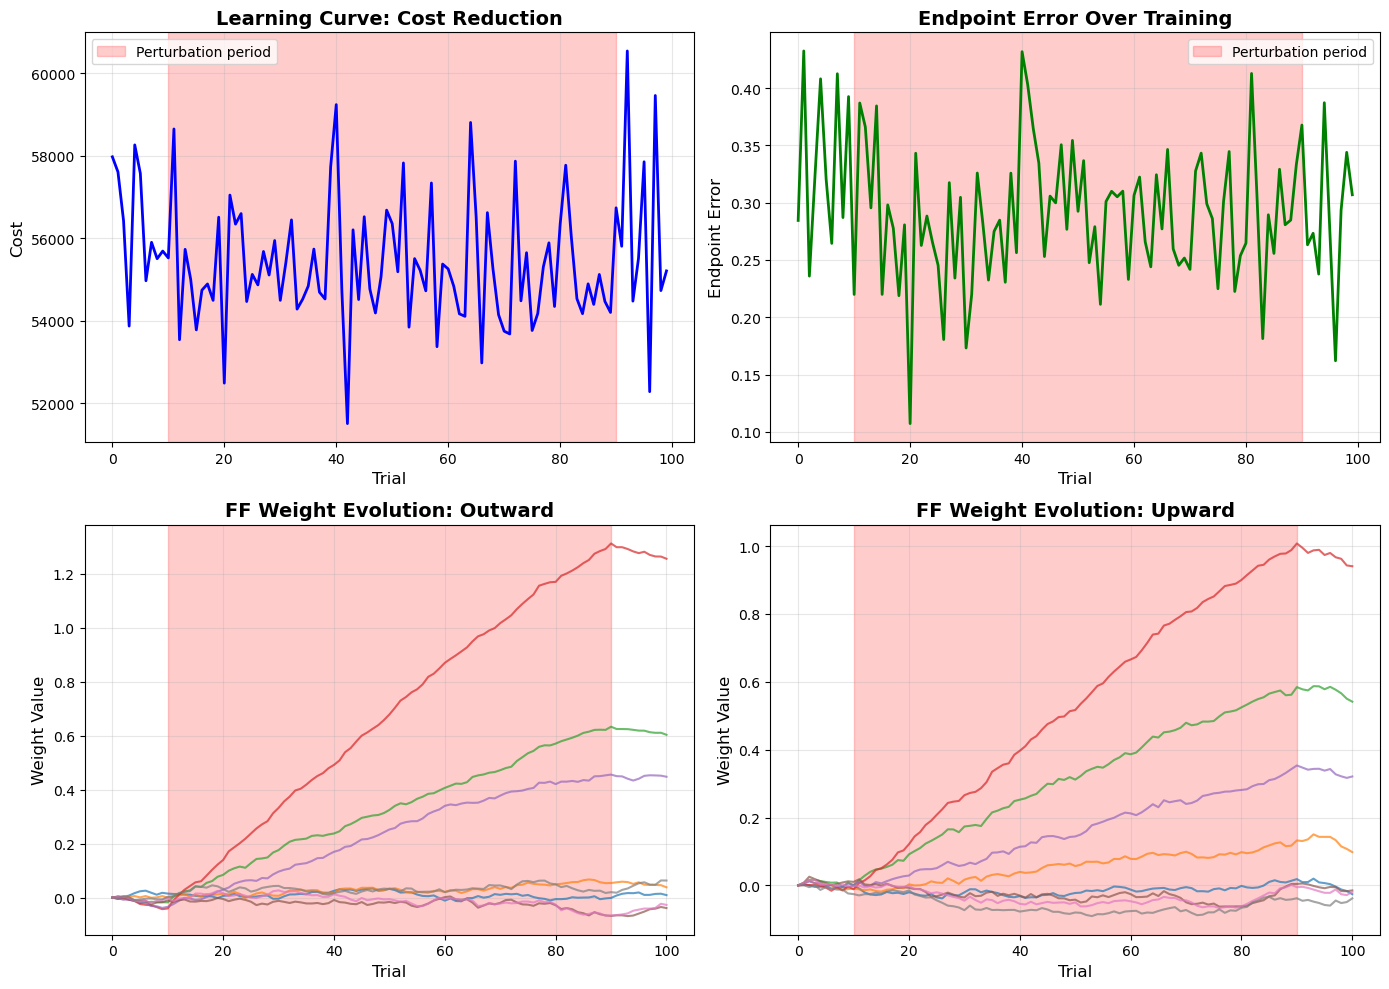

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cost over trials
ax = axes[0, 0]
ax.plot(training_results['cost_history'], 'b-', linewidth=2)
ax.axvspan(10, 90, alpha=0.2, color='red', label='Perturbation period')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Cost', fontsize=12)
ax.set_title('Learning Curve: Cost Reduction', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Endpoint error over trials
ax = axes[0, 1]
ax.plot(training_results['endpoint_error_history'], 'g-', linewidth=2)
ax.axvspan(10, 90, alpha=0.2, color='red', label='Perturbation period')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Endpoint Error', fontsize=12)
ax.set_title('Endpoint Error Over Training', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Weight evolution - outward direction
ax = axes[1, 0]
for i in range(Phi.shape[1]):
    ax.plot(training_results['ff_weights_history'][:, i, 0], alpha=0.7, label=f'Basis {i+1}')
ax.axvspan(10, 90, alpha=0.2, color='red')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Weight Value', fontsize=12)
ax.set_title('FF Weight Evolution: Outward', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Weight evolution - upward direction
ax = axes[1, 1]
for i in range(Phi.shape[1]):
    ax.plot(training_results['ff_weights_history'][:, i, 1], alpha=0.7, label=f'Basis {i+1}')
ax.axvspan(10, 90, alpha=0.2, color='red')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Weight Value', fontsize=12)
ax.set_title('FF Weight Evolution: Upward', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Compare Trajectories: Early vs Late Learning

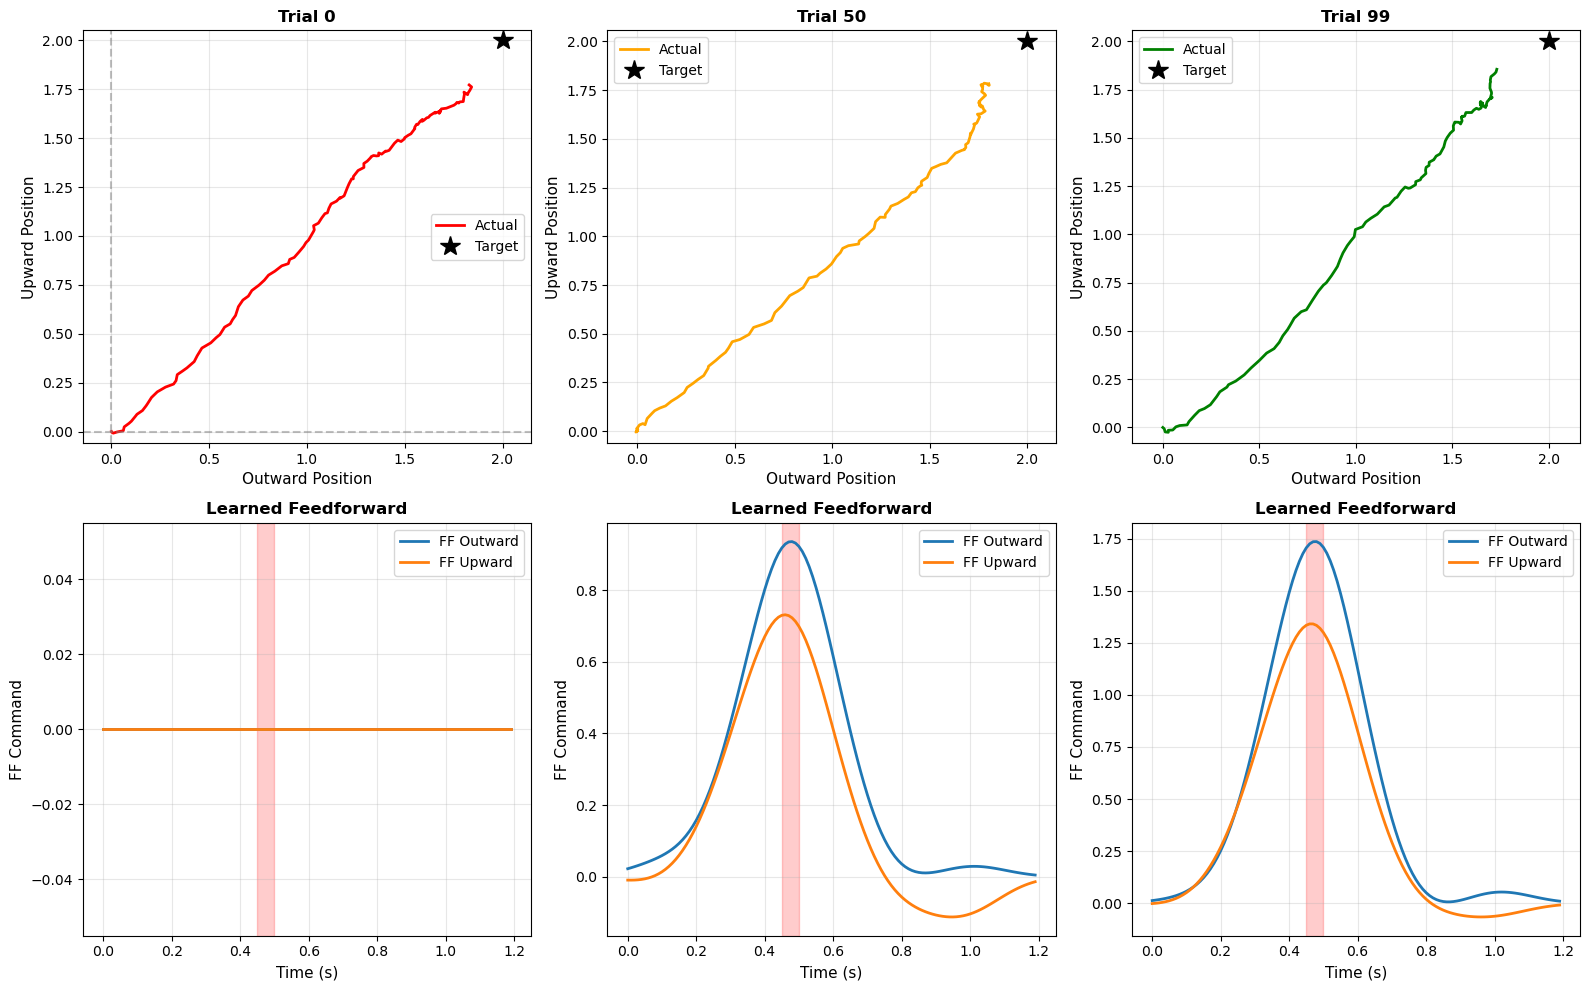

In [5]:
# Get saved trials
trial_early = training_results['trials'][0]
trial_mid = training_results['trials'][50]
trial_late = training_results['trials'][99]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot trajectories for each phase
for idx, (trial_num, trial_data, color) in enumerate([
    (0, trial_early, 'red'),
    (50, trial_mid, 'orange'),
    (99, trial_late, 'green')
]):
    # Position trajectory
    ax = axes[0, idx]
    ax.plot(trial_data['x'][:, 0], trial_data['x'][:, 1], color=color, linewidth=2, label='Actual')
    ax.plot(params.target[0], params.target[1], 'k*', markersize=15, label='Target')
    if idx == 0:
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Outward Position', fontsize=11)
    ax.set_ylabel('Upward Position', fontsize=11)
    ax.set_title(f'Trial {trial_num}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # Feedforward command
    ax = axes[1, idx]
    t = np.arange(len(trial_data['u_ff'])) * params.dt
    ax.plot(t, trial_data['u_ff'][:, 0], label='FF Outward', linewidth=2)
    ax.plot(t, trial_data['u_ff'][:, 1], label='FF Upward', linewidth=2)
    ax.axvspan(inta_pert.onset_idx * params.dt, 
               (inta_pert.onset_idx + inta_pert.duration) * params.dt,
               alpha=0.2, color='red')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('FF Command', fontsize=11)
    ax.set_title(f'Learned Feedforward', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Scenario 2: Washout - Removing the Perturbation

Test what happens when the perturbation is removed after learning.

Testing washout (perturbation removed)...


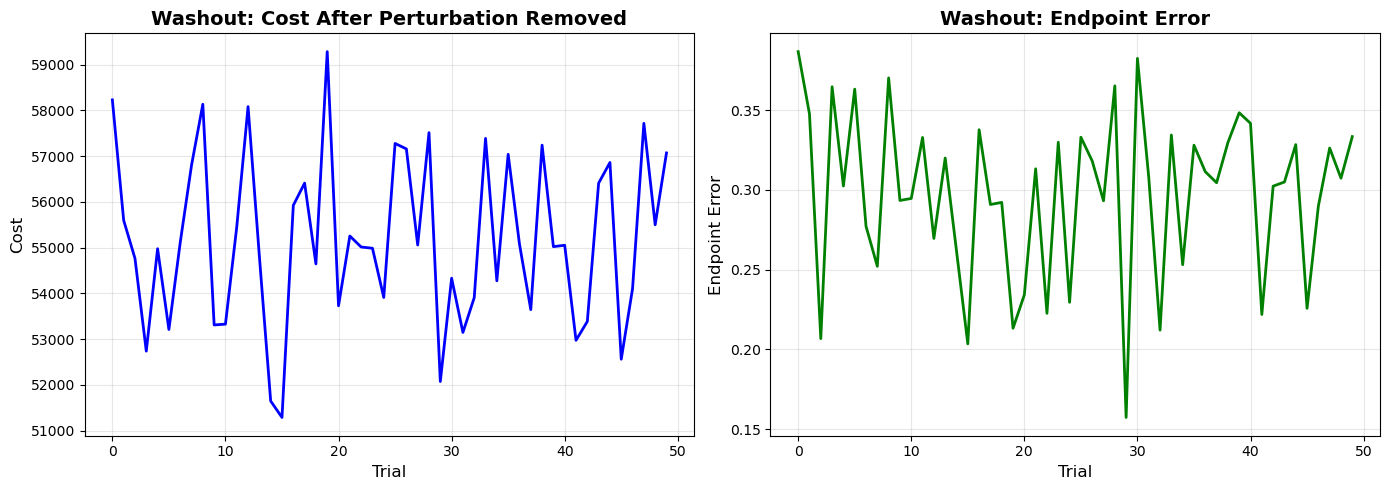


Washout: Initial cost: 58227.91
Washout: Final cost: 57067.81


In [6]:
# Continue training without perturbation (washout)
print("Testing washout (perturbation removed)...")
washout_results = train_with_adaptation(
    controller=controller,
    Phi=Phi,
    n_trials=50,
    perturbation=None,  # No perturbation
    rng=np.random.default_rng(43)
)

# Plot washout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(washout_results['cost_history'], 'b-', linewidth=2)
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Cost', fontsize=12)
ax.set_title('Washout: Cost After Perturbation Removed', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(washout_results['endpoint_error_history'], 'g-', linewidth=2)
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Endpoint Error', fontsize=12)
ax.set_title('Washout: Endpoint Error', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWashout: Initial cost: {washout_results['cost_history'][0]:.2f}")
print(f"Washout: Final cost: {washout_results['cost_history'][-1]:.2f}")

### Summary Statistics

In [7]:
# Create summary dataframe
summary_data = {
    'Phase': ['Pre-perturbation (trials 0-10)', 'Early adaptation (trials 10-30)', 
              'Late adaptation (trials 70-90)', 'Post-perturbation (trials 90-100)'],
    'Mean Cost': [
        training_results['cost_history'][0:10].mean(),
        training_results['cost_history'][10:30].mean(),
        training_results['cost_history'][70:90].mean(),
        training_results['cost_history'][90:100].mean()
    ],
    'Mean Endpoint Error': [
        training_results['endpoint_error_history'][0:10].mean(),
        training_results['endpoint_error_history'][10:30].mean(),
        training_results['endpoint_error_history'][70:90].mean(),
        training_results['endpoint_error_history'][90:100].mean()
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(2))

,Phase,Mean Cost,Mean Endpoint Error
0,Pre-perturbation (trials 0-10),56375.76,0.34
1,Early adaptation (trials 10-30),55324.90,0.27
2,Late adaptation (trials 70-90),55040.08,0.29
3,Post-perturbation (trials 90-100),56258.96,0.29
